In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_parquet("../data/e-commerce-dataset.parquet")

In [4]:
df.head()

,Distance_Miles,Traffic_Delay_Hrs,Weather_Delay_Hrs,Warehouse_Region,Delivery_Time_Hrs
0,193.524658,2.839811,2.654163,West_Hub,38.770662
1,475.850010,0.049788,5.653889,South_Hub,80.602022
2,368.677031,0.044744,3.845051,West_Hub,59.871281
3,303.342657,0.781972,3.630492,East_Hub,51.868008
4,86.449134,1.341375,2.346917,South_Hub,24.662365


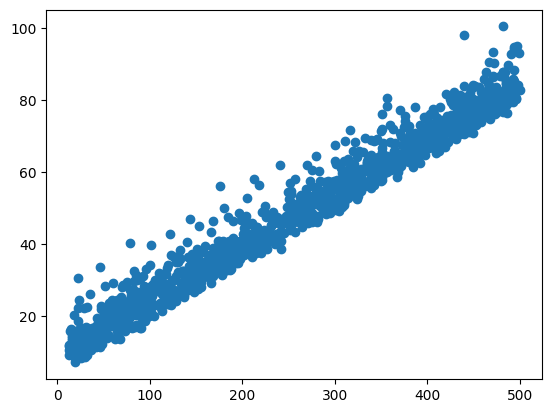

In [5]:
plt.scatter(df.Distance_Miles,df.Delivery_Time_Hrs)

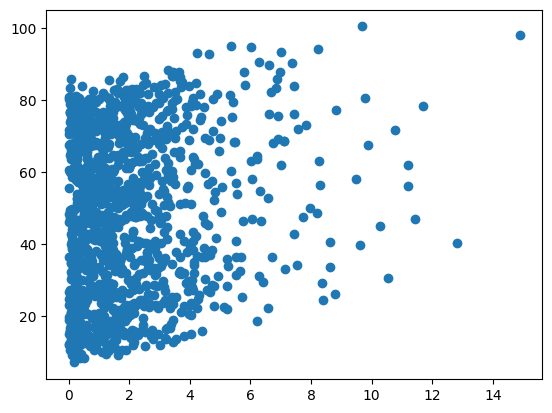

In [6]:
plt.scatter(df.Traffic_Delay_Hrs,df.Delivery_Time_Hrs)

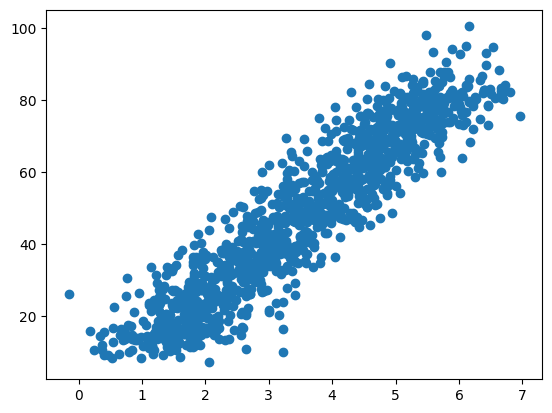

In [7]:
plt.scatter(df.Weather_Delay_Hrs,df.Delivery_Time_Hrs)

In [8]:
import seaborn as sns

Text(0.5, 1.0, 'Delivery Time Distribution by Warehouse Region')

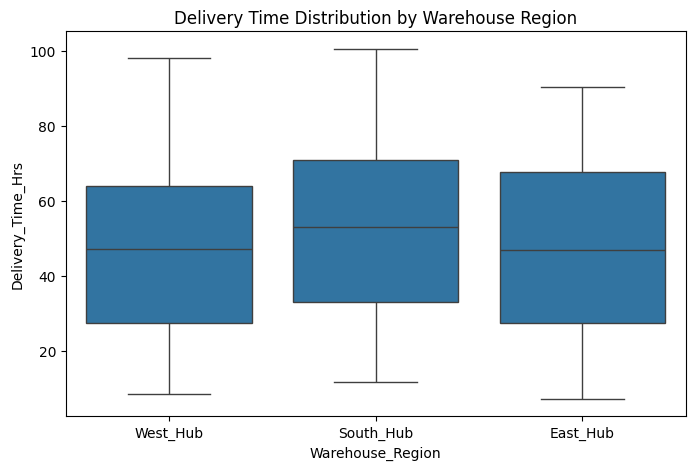

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Warehouse_Region',y='Delivery_Time_Hrs',data=df)
plt.title('Delivery Time Distribution by Warehouse Region')

### Data Engineering and Architecture

In [10]:
import statsmodels.api as sm
import sklearn
from sklearn.model_selection import train_test_split

In [11]:
df.head()

,Distance_Miles,Traffic_Delay_Hrs,Weather_Delay_Hrs,Warehouse_Region,Delivery_Time_Hrs
0,193.524658,2.839811,2.654163,West_Hub,38.770662
1,475.850010,0.049788,5.653889,South_Hub,80.602022
2,368.677031,0.044744,3.845051,West_Hub,59.871281
3,303.342657,0.781972,3.630492,East_Hub,51.868008
4,86.449134,1.341375,2.346917,South_Hub,24.662365


In [12]:
# Vertical Split
X=df.drop('Delivery_Time_Hrs',axis=1)
Y=df.Delivery_Time_Hrs

In [13]:
print(Y.value_counts())

Delivery_Time_Hrs
38.770662    1
80.602022    1
59.871281    1
51.868008    1
24.662365    1
            ..
71.910442    1
79.313382    1
83.351099    1
65.670514    1
20.383830    1
Name: count, Length: 1200, dtype: int64


In [14]:
wh_dummy=pd.get_dummies(X.Warehouse_Region,drop_first=True,prefix='WH').astype(int)
X.drop('Warehouse_Region',axis=1,inplace=True)
X=pd.concat([X,wh_dummy],axis=1)

In [15]:
X.head()

,Distance_Miles,Traffic_Delay_Hrs,Weather_Delay_Hrs,WH_South_Hub,WH_West_Hub
0,193.524658,2.839811,2.654163,0,1
1,475.850010,0.049788,5.653889,1,0
2,368.677031,0.044744,3.845051,0,1
3,303.342657,0.781972,3.630492,0,0
4,86.449134,1.341375,2.346917,1,0


In [16]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=20,)

In [17]:
x_train.head()
# x_test.head()

,Distance_Miles,Traffic_Delay_Hrs,Weather_Delay_Hrs,WH_South_Hub,WH_West_Hub
1083,440.767971,0.093447,4.854533,1,0
909,196.049280,8.211394,2.784532,0,1
308,399.641235,1.872503,3.890481,1,0
237,21.914824,2.439397,0.718055,1,0
404,166.824305,0.143903,1.805340,1,0


In [18]:
x_train=sm.add_constant(x_train,prepend=False) # prepend = False means constant column appears last
x_train.head()

,Distance_Miles,Traffic_Delay_Hrs,Weather_Delay_Hrs,WH_South_Hub,WH_West_Hub,const
1083,440.767971,0.093447,4.854533,1,0,1.0
909,196.049280,8.211394,2.784532,0,1,1.0
308,399.641235,1.872503,3.890481,1,0,1.0
237,21.914824,2.439397,0.718055,1,0,1.0
404,166.824305,0.143903,1.805340,1,0,1.0


In [19]:
# Defining the model 
model1=sm.OLS(y_train,x_train)

# fitting the model to calculate coefficients
results=model1.fit()

#printing the comprehensive regression metrics
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:      Delivery_Time_Hrs   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 9.307e+04
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:49:27   Log-Likelihood:                -1355.8
No. Observations:                 960   AIC:                             2724.
Df Residuals:                     954   BIC:                             2753.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Distance_Miles        0.1503      0.00

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [21]:
x_train.head()

,Distance_Miles,Traffic_Delay_Hrs,Weather_Delay_Hrs,WH_South_Hub,WH_West_Hub,const
1083,440.767971,0.093447,4.854533,1,0,1.0
909,196.049280,8.211394,2.784532,0,1,1.0
308,399.641235,1.872503,3.890481,1,0,1.0
237,21.914824,2.439397,0.718055,1,0,1.0
404,166.824305,0.143903,1.805340,1,0,1.0


In [22]:
# x_train.values
x_train.shape[1]
x_train.values[1]

array([196.04928   ,   8.21139424,   2.78453214,   0.        ,
         1.        ,   1.        ])

In [23]:
vif_df=pd.DataFrame() # empty dataframe to store the results cleanly
vif_df["Features"]=x_train.columns
vif_df["VIF"]=[variance_inflation_factor(x_train.values,i) for i in range(x_train.shape[1])]
print(vif_df)

            Features        VIF
0     Distance_Miles   9.301669
1  Traffic_Delay_Hrs   1.002202
2  Weather_Delay_Hrs   9.299161
3       WH_South_Hub   1.407285
4        WH_West_Hub   1.405515
5              const  12.114778


In [24]:
x_test.head()

,Distance_Miles,Traffic_Delay_Hrs,Weather_Delay_Hrs,WH_South_Hub,WH_West_Hub
296,387.296841,1.932487,4.713045,0,1
590,78.025315,0.325436,1.398610,0,1
439,49.860903,5.234618,1.709402,0,0
1040,274.350733,3.165380,3.655725,0,0
561,114.352439,3.720382,2.556548,0,0


In [25]:
#Stripping out hidden spaces
x_train.columns = x_train.columns.str.strip()
x_test.columns = x_test.columns.str.strip()


x_train.drop('Weather_Delay_Hrs',axis=1,inplace=True,errors='ignore')
x_test.drop('Weather_Delay_Hrs',axis=1,inplace=True,errors='ignore')

In [26]:
print(x_test.columns.to_list())

['Distance_Miles', 'Traffic_Delay_Hrs', 'WH_South_Hub', 'WH_West_Hub']


In [27]:
model2=sm.OLS(y_train,x_train) # lazy - preparing the blueprint in RAM

# fitting the model inside our computer's RAM to calculate coefficients
results=model2.fit() # Running the heavy calculation in RAM

print(results.summary())


                            OLS Regression Results                            
Dep. Variable:      Delivery_Time_Hrs   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 1.164e+05
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:49:28   Log-Likelihood:                -1356.0
No. Observations:                 960   AIC:                             2722.
Df Residuals:                     955   BIC:                             2746.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Distance_Miles        0.1498      0.00

Model is clean, mathematically stable.

### Production Pipeline

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

In [88]:
x_train_num=x_train[['Distance_Miles','Traffic_Delay_Hrs']]
x_train_dum=x_train[['WH_South_Hub','WH_West_Hub']].reset_index(drop=True)

In [89]:
x_test_num=x_test[['Distance_Miles','Traffic_Delay_Hrs']]
x_test_dum=x_test[['WH_South_Hub','WH_West_Hub']].reset_index(drop=True)

In [90]:
len(x_test_num)

240

In [85]:
x_test_num.head()

,Distance_Miles,Traffic_Delay_Hrs
1083,440.767971,0.093447
909,196.049280,8.211394
308,399.641235,1.872503
237,21.914824,2.439397
404,166.824305,0.143903


In [91]:
# Applying StandardScaler ONLY to CONTINUOUS Data
scaler=StandardScaler()


In [92]:
x_train_num_scaled=pd.DataFrame(scaler.fit_transform(x_train_num),columns=x_train_num.columns)
x_test_num_scaled=pd.DataFrame(scaler.transform(x_test_num),columns=x_test_num.columns)

In [93]:
x_train_num_scaled.head()

,Distance_Miles,Traffic_Delay_Hrs
0,1.284253,-0.939696
1,-0.426045,3.103006
2,0.996825,-0.053734
3,-1.643042,0.228577
4,-0.630294,-0.914569


In [94]:
x_train_final = pd.concat([x_train_num_scaled,x_train_dum],axis=1)
x_test_final = pd.concat([x_test_num_scaled,x_test_dum],axis=1)

In [95]:
x_train_final.head()

,Distance_Miles,Traffic_Delay_Hrs,WH_South_Hub,WH_West_Hub
0,1.284253,-0.939696,1,0
1,-0.426045,3.103006,0,1
2,0.996825,-0.053734,1,0
3,-1.643042,0.228577,1,0
4,-0.630294,-0.914569,1,0


### Training Production Ridge Regression Model (L2 Regularization)

In [96]:
ridge_prod=Ridge(alpha=0.1)
ridge_prod.fit(x_train_final,y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [100]:
test_predictions=ridge_prod.predict(x_test_final)

In [101]:
len(test_predictions)

240

In [102]:
final_mse=mean_squared_error(y_test,test_predictions)

In [103]:
print("PRODCUTION PIPELINE SUCCESSFULL")
print(f"Final Test Mean Squared Error(MSE): {final_mse:.4f}")

PRODCUTION PIPELINE SUCCESSFULL
Final Test Mean Squared Error(MSE): 0.8873
